In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
df=pd.read_csv(r"C:\Users\Mohammad zaid arif\OneDrive\Documents\insurance ml model\insurance.csv")

In [12]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [14]:
df.shape

(1340, 10)

In [15]:
df.dropna(inplace=True)

In [16]:
df.drop(columns="Id",inplace=True)

In [17]:
df.describe()

,age,bmi,bloodpressure,children,claim
count,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000
mean,38.086336,30.658333,94.189189,1.099850,13325.246426
std,11.112804,6.118967,11.445173,1.205958,12109.620712
min,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,29.000000,26.200000,86.000000,0.000000,4760.157500
50%,38.000000,30.350000,92.000000,1.000000,9412.965000
75%,47.000000,34.725000,99.000000,2.000000,16781.327500
max,60.000000,53.100000,140.000000,5.000000,63770.430000


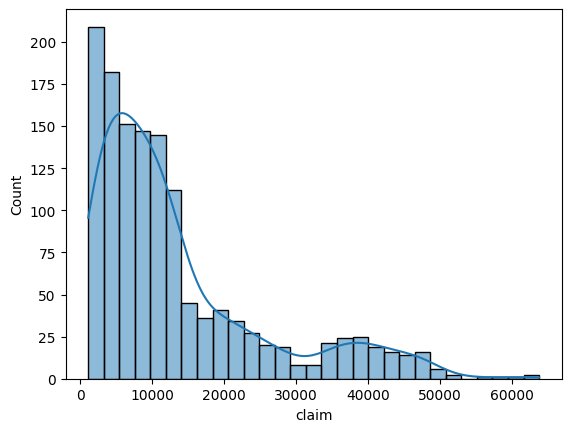

In [18]:
sns.histplot(df["claim"],kde=True)
plt.show()

In [19]:
df_numeric_cols=df[["age","bmi","bloodpressure","children","claim"]]

In [20]:
df_numeric_cols.head()

,age,bmi,bloodpressure,children,claim
0,39.0,23.2,91,0,1121.87
1,24.0,30.1,87,0,1131.51
7,19.0,41.1,100,0,1146.80
8,20.0,43.0,86,0,1149.40
9,30.0,53.1,97,0,1163.46


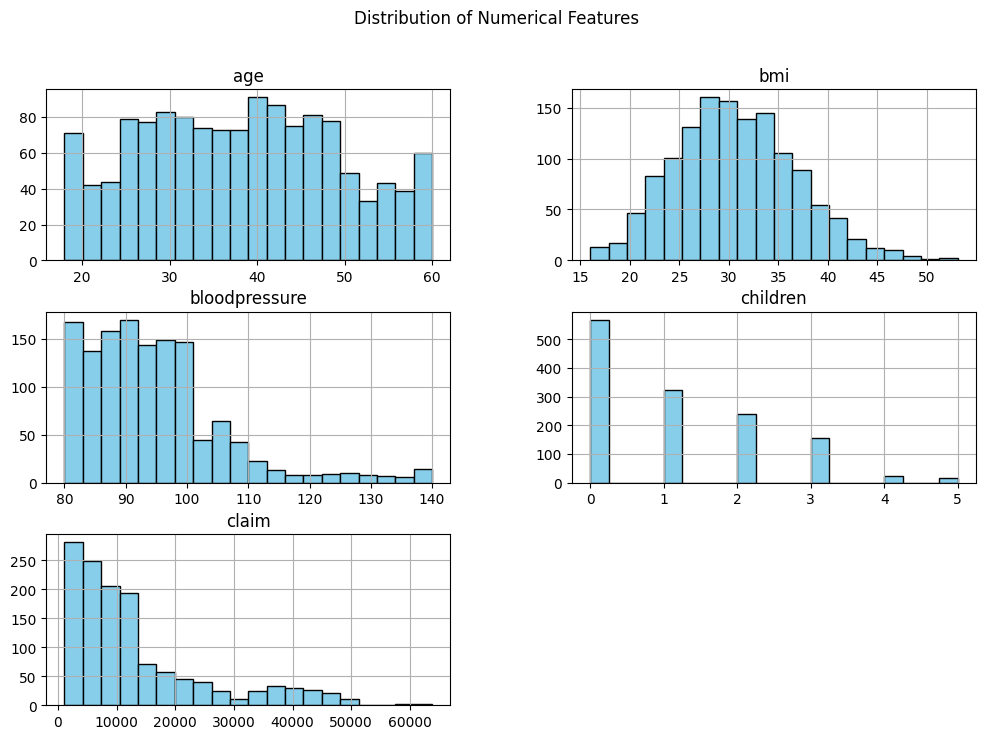

In [21]:
df_numeric_cols.hist(bins=20,figsize=(12,8),color="skyblue",edgecolor="black")
plt.suptitle("Distribution of Numerical Features")
plt.show()

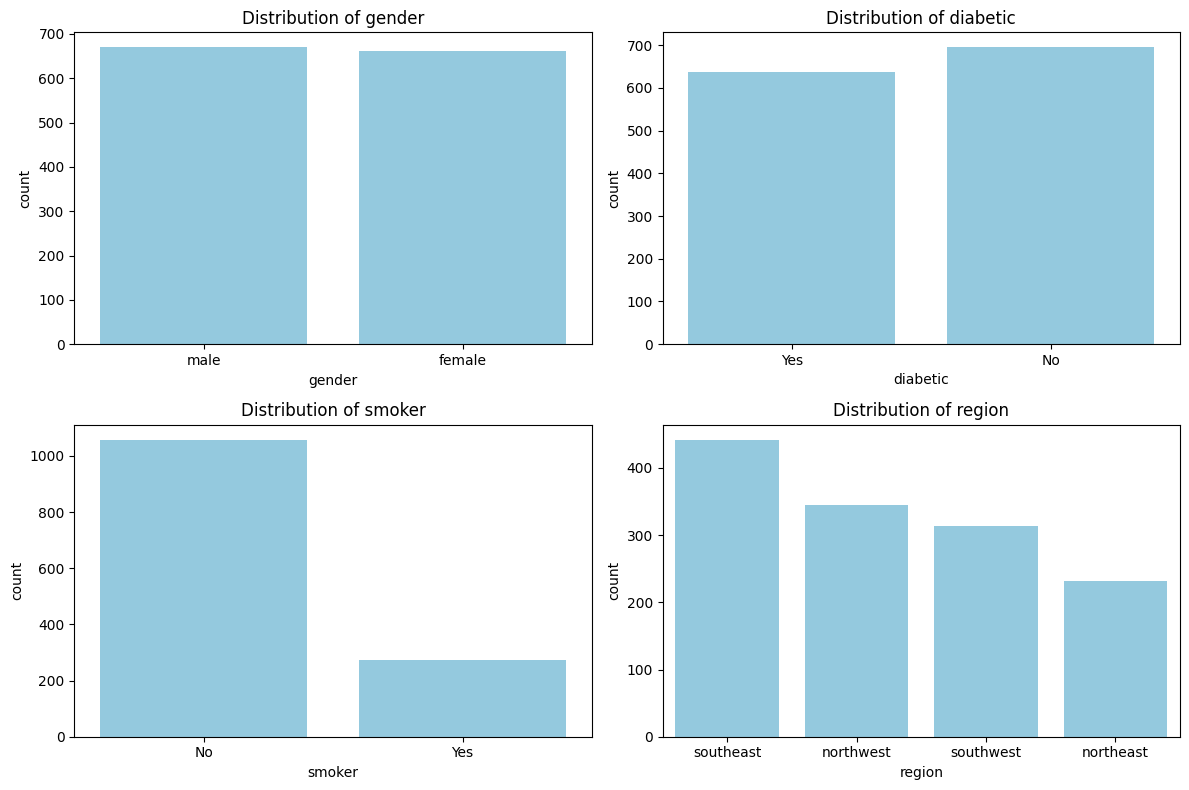

In [22]:
cat_cols=["gender","diabetic","smoker","region"]
plt.figure(figsize=(12,8))
for i,col in enumerate(cat_cols,1):
    plt.subplot(2,2,i)
    sns.countplot(data=df,x=col,color="skyblue")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [23]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No         8762.30
        Yes       30679.00
male    No         8169.25
        Yes       33042.01
Name: claim, dtype: float64

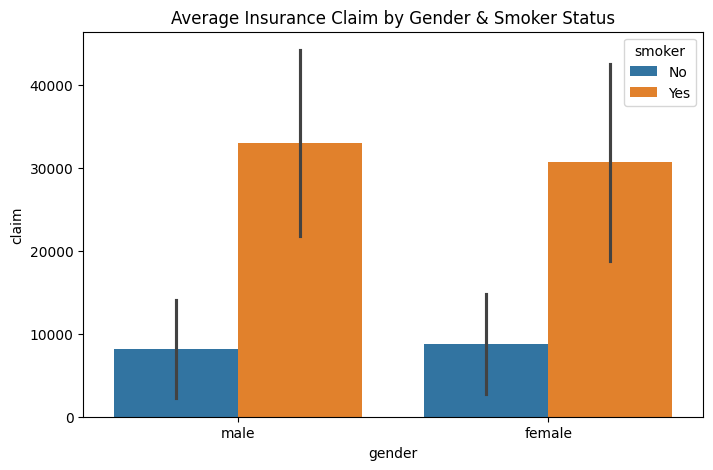

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="gender",y="claim",hue="smoker",estimator="mean",errorbar="sd")
plt.title("Average Insurance Claim by Gender & Smoker Status")
plt.show()

In [25]:
region_diabetics=df.groupby(["region","diabetic"])["claim"].mean().unstack()
region_diabetics

diabetic,No,Yes
region,,
northeast,16966.861455,16818.302231
northwest,11442.831842,12224.958000
southeast,13578.717200,12574.093226
southwest,13069.907824,12313.739167


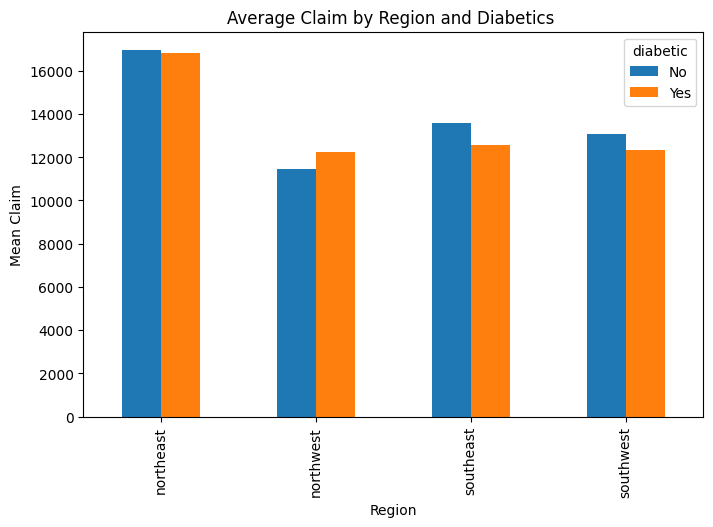

In [26]:
region_diabetics.plot(kind="bar",figsize=(8,5))
plt.title("Average Claim by Region and Diabetics ")
plt.ylabel("Mean Claim")
plt.xlabel("Region")
plt.show()

In [27]:
pivot_table=df.pivot_table(
    values="claim",
    index="region",
    columns="smoker",
    aggfunc="mean",
)
pivot_table

smoker,No,Yes
region,,
northeast,11666.112195,29673.536269
northwest,8076.203415,30192.002759
southeast,7444.144872,34844.997253
southwest,8294.754102,32269.064138


In [28]:
pivot_table=df.pivot_table(
    values="claim",
    index='children',
    columns='diabetic',
    aggfunc='mean'
)
pivot_table
    

diabetic,No,Yes
children,,
0,12967.395398,11985.289857
1,12730.455810,12732.055724
2,15567.767583,14579.360417
3,13807.612892,17091.258649
4,14106.630000,13573.352500
5,8519.043636,9205.594286


In [29]:
df_numeric_cols.corr()

,age,bmi,bloodpressure,children,claim
age,1.000000,-0.042152,-0.060322,-0.026208,-0.028636
bmi,-0.042152,1.000000,0.144977,0.013719,0.199945
bloodpressure,-0.060322,0.144977,1.000000,-0.034356,0.531263
children,-0.026208,0.013719,-0.034356,1.000000,0.064149
claim,-0.028636,0.199945,0.531263,0.064149,1.000000


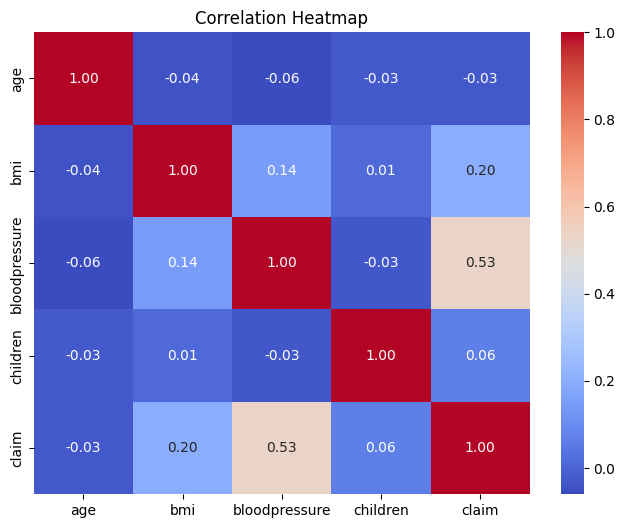

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric_cols.corr(),annot=True ,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

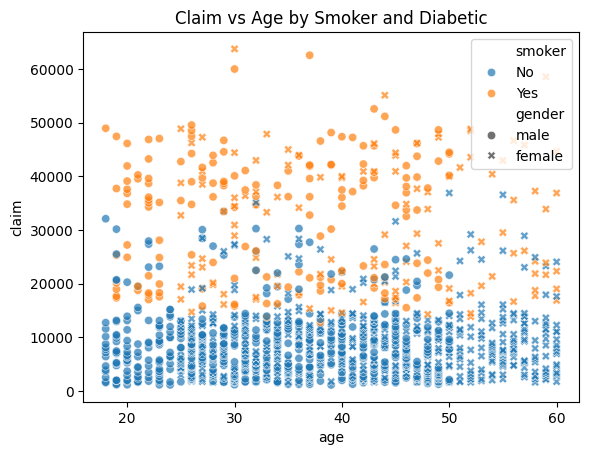

In [31]:
sns.scatterplot(data=df,
                x='age',
                y='claim',
                hue='smoker',
                style='gender',
                alpha=0.7
)
plt.title("Claim vs Age by Smoker and Diabetic")
plt.show()

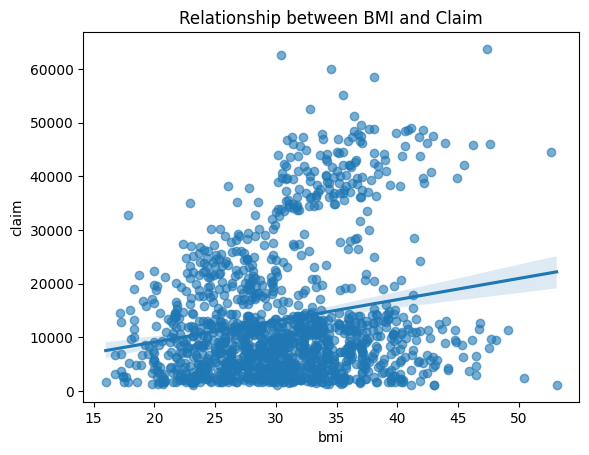

In [32]:
sns.regplot(data=df,
            x='bmi',
            y='claim',
            scatter_kws={"alpha":0.6}
           )
plt.title("Relationship between BMI and Claim")
plt.show()

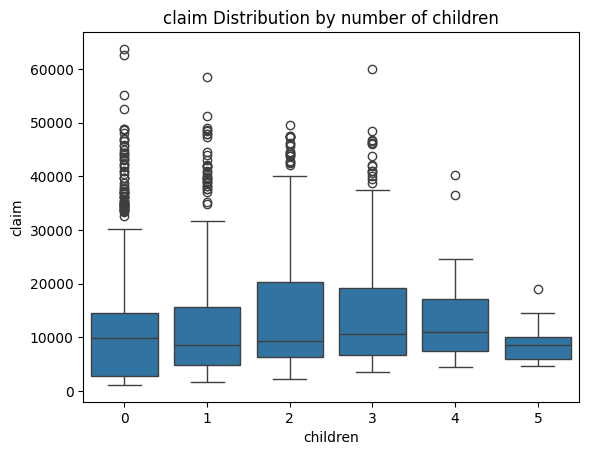

In [33]:
sns.boxplot(data=df,
            x='children',
            y='claim'
           )
plt.title("claim Distribution by number of children")
plt.show()

In [34]:
df["age_group"]=pd.cut(df["age"],bins=[0,18,30,45,60],labels=['<18','18-30','31-45','46-60'])
df.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,31-45
1,24.0,male,30.1,87,No,0,No,southeast,1131.51,18-30
7,19.0,male,41.1,100,No,0,No,northwest,1146.80,18-30
8,20.0,male,43.0,86,No,0,No,northwest,1149.40,18-30
9,30.0,male,53.1,97,No,0,No,northwest,1163.46,18-30


In [35]:
df["age_group"].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
Name: count, dtype: int64

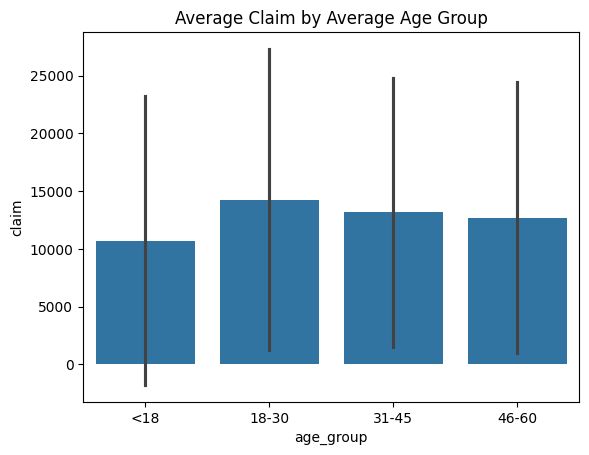

In [36]:
sns.barplot(data=df,
            x='age_group',
            y='claim',
            estimator='mean',
            errorbar='sd'
           )
plt.title("Average Claim by Average Age Group")
plt.show()

In [37]:
df["bmi_category"]=pd.cut(df["bmi"],bins=[0,18.5,24.9,29.9,100],labels=['Underweight','Normal','Overweight','Obese'])
df.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group,bmi_category
0,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,31-45,Normal
1,24.0,male,30.1,87,No,0,No,southeast,1131.51,18-30,Obese
7,19.0,male,41.1,100,No,0,No,northwest,1146.80,18-30,Obese
8,20.0,male,43.0,86,No,0,No,northwest,1149.40,18-30,Obese
9,30.0,male,53.1,97,No,0,No,northwest,1163.46,18-30,Obese


In [38]:
df['bmi_category'].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

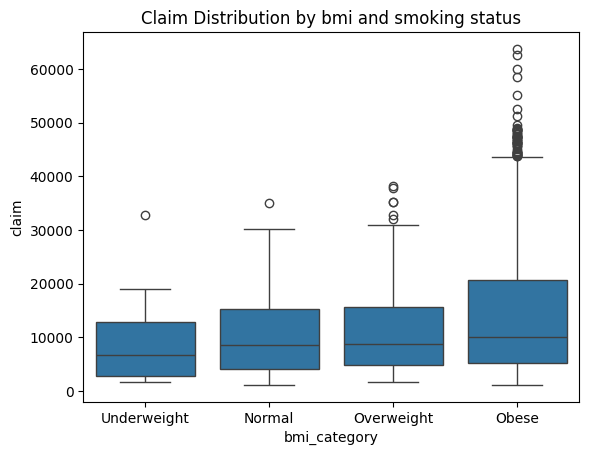

In [39]:
sns.boxplot(data=df,
             x="bmi_category",
             y="claim"
            )
plt.title("Claim Distribution by bmi and smoking status")
plt.show()

In [40]:
region_stats=df.groupby("region").agg(
    smoker_rate=("smoker",lambda x: (x=="Yes").mean()*100),
    mean_claim=("claim","mean")
)

In [41]:
region_stats

,smoker_rate,mean_claim
region,,
northeast,29.004329,16889.044719
northwest,16.811594,11794.221855
southeast,20.588235,13085.496833
southwest,18.471338,12723.129841


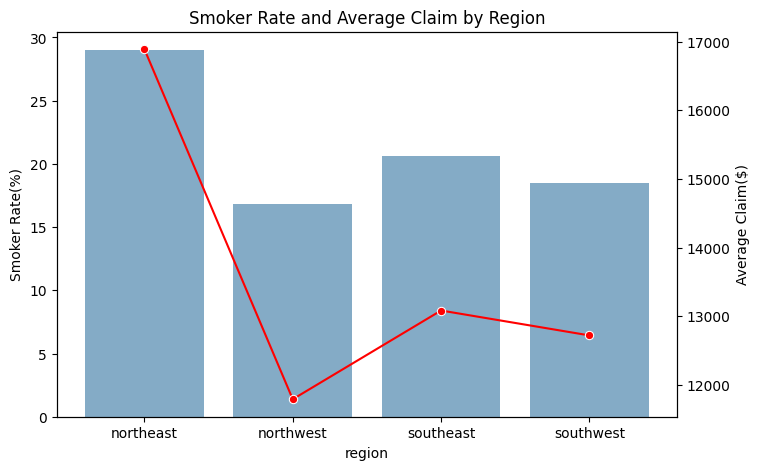

In [42]:
fig,ax1=plt.subplots(figsize=(8,5))

sns.barplot(data=region_stats,
            x='region',
            y='smoker_rate',
            ax=ax1,
            alpha=0.6
           )
ax2=ax1.twinx()
sns.lineplot(data=region_stats,
             x='region',
             y='mean_claim',
             color="red",
             marker='o'
            )
ax1.set_ylabel("Smoker Rate(%)")
ax2.set_ylabel("Average Claim($)")
plt.title("Smoker Rate and Average Claim by Region")
plt.show()
             

In [43]:
df.columns

Index(['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [45]:
import warnings
warnings.filterwarnings("ignore")

In [46]:
X=df[['age','gender','bmi','bloodpressure','diabetic','children','smoker']]
y=df[['claim']]

In [47]:
cat_cols=['gender','diabetic','smoker']
label_encoder={}

for col in cat_cols:
    le=LabelEncoder()
    X[col]=le.fit_transform(X[col])
    label_encoder[col]=le

    joblib.dump(le, f"label_encoder_{col}.pkl")

In [48]:
label_encoder

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [67]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2)


In [69]:
num_cols=['age','bmi','bloodpressure','children']
scaler=StandardScaler()

In [70]:
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [71]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [73]:
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(1065, 7) (1065, 1) (267, 7) (267, 1)


In [154]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV , cross_val_score
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from xgboost import XGBRegressor

In [155]:
def evaluate_model(model, X_train,X_test,y_train,y_test):
    y_pred=model.predict(X_test)
    r2=r2_score(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred)).item()

    return {"R2": r2 , "MAE": mae , "RMSE": rmse}

In [156]:
results={}

In [157]:
lr=LinearRegression()
lr.fit(X_train,y_train)
results["Linear Regression"]=evaluate_model(lr,X_train,X_test,y_train,y_test) 
print("Linear Regression model trained")

best_poly_model=None
best_poly_score=-np.inf

for degree in [2,3]:
    poly =PolynomialFeatures(degree= degree)
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.transform(X_test)

    poly_lr=LinearRegression()
    poly_lr.fit(X_train_poly,y_train)
    score=poly_lr.score(X_test_poly,y_test)

    if score>best_poly_score :
        best_poly_score=score
        best_poly_model=(degree,poly,poly_lr)

degree,poly,poly_lr=best_poly_model
results[f"Polynimial Regression (deg = {degree})"] = evaluate_model(poly_lr,poly.fit_transform(X_train),poly.transform(X_test),y_train,y_test)

print("Polynomial Regression model trained")


rf=RandomForestRegressor()

rf_params={
    "n_estimators":[100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

rf_grid=GridSearchCV(rf,rf_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
rf_grid.fit(X_train,y_train)
best_rf=rf_grid.best_estimator_

results["Random Forest"]= evaluate_model(best_rf,X_train,X_test,y_train,y_test)
print("Random Forest model trained, best parameter:",rf_grid.best_params_)

svr=SVR()

svr_params={
    "kernel":["rbf","poly","linear"],
    "C":[1,10,50],
    "epsilon":[0.1,0.2,0.5],
    "degree":[2,3]
}

svr_grid=GridSearchCV(svr,svr_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
svr_grid.fit(X_train,y_train)
best_svr=svr_grid.best_estimator_

results["SVR"]=evaluate_model(best_svr,X_train,X_test,y_train,y_test)
print("SVR training is completed, best parameters:", svr_grid.best_params_)


xgb=XGBRegressor(objective="reg:squarederror")
xgb_params={
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.8,1.0]
}
xgb_grid=GridSearchCV(xgb,xgb_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
xgb_grid.fit(X_train,y_train)
best_xgb=xgb_grid.best_estimator_

results["XGBRegressor"] = evaluate_model(best_xgb,X_train,X_test,y_train,y_test)
print("XGBRegressor training is completed, best parameters:",xgb_grid.best_params_)

Linear Regression model trained
Polynomial Regression model trained
Random Forest model trained, best parameter: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
SVR training is completed, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.5, 'kernel': 'linear'}
XGBRegressor training is completed, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [158]:
print(results)

{'Linear Regression': {'R2': 0.6892781093367242, 'MAE': 4848.602484485999, 'RMSE': 6544.543415622022}, 'Polynimial Regression (deg = 3)': {'R2': 0.7243989279696186, 'MAE': 4451.9499248927705, 'RMSE': 6163.591945705802}, 'Random Forest': {'R2': 0.766561231998234, 'MAE': 4202.614039201836, 'RMSE': 5672.570720195553}, 'SVR': {'R2': 0.5163295976905949, 'MAE': 5624.01883375607, 'RMSE': 8165.225509553074}, 'XGBRegressor': {'R2': 0.7846692800521851, 'MAE': 4058.17236328125, 'RMSE': 5448.116738837375}}


In [159]:
results_df=pd.DataFrame(results).T.sort_values(by="R2",ascending=False).round(2)
results_df.head()

,R2,MAE,RMSE
XGBRegressor,0.78,4058.17,5448.12
Random Forest,0.77,4202.61,5672.57
Polynimial Regression (deg = 3),0.72,4451.95,6163.59
Linear Regression,0.69,4848.60,6544.54
SVR,0.52,5624.02,8165.23


In [170]:
models={
    "Linear Regression":lr,
    "Polynomial Regressor": poly_lr,
    "Random Forest": best_rf,
    "SVR":best_svr,
    "XGBRegressor":best_xgb
}

In [171]:
best_r2=results_df["R2"].max()

In [172]:
best_r2

np.float64(0.78)

In [173]:
top_model= results_df[results_df["R2"] == best_r2]

In [174]:
top_model

,R2,MAE,RMSE
XGBRegressor,0.78,4058.17,5448.12


In [175]:
best_model=models[top_model.index[0]]

In [176]:
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [177]:
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [179]:
print(f"Best model selected :{top_model.index[0]}")

Best model selected :XGBRegressor
